<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> 书的补充代码，作者：<a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码库：<a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第 5 章：无标签数据的预训练（Chapter 5: Pretraining on Unlabeled Data）

In [1]:
from importlib.metadata import PackageNotFoundError, version

def get_package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        # Windows 安装的是 tensorflow-cpu，但导入时仍使用 tensorflow。
        if package_name == "tensorflow":
            return version("tensorflow-cpu")
        raise

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # 对于 OpenAI 的预训练权重
       ]
for p in pkgs:
    print(f"{p} version: {get_package_version(p)}")

matplotlib version: 3.11.0
numpy version: 1.26.4
tiktoken version: 0.13.0
torch version: 2.7.1+cu118
tensorflow version: 2.21.0


- 在本章中，我们实现了基本模型评估的训练循环和代码，以预训练 LLM
- 在本章末尾，我们还将 OpenAI 中公开可用的预训练权重加载到我们的模型中

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/01.webp" width=1000px>

- 本章涵盖的主题如下所示

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=1000px>

 
## 5.1 评估生成文本模型（5.1 Evaluating generative text models）

- 我们首先简要回顾一下使用上一章中的代码初始化 GPT 模型
- 然后，我们讨论LLM的基本评估指标
- 最后，在本节中，我们将这些评估指标应用于训练和验证数据集

 
### 5.1.1 使用 GPT 生成文本（5.1.1 Using GPT to generate text）

- 我们使用上一章中的代码初始化 GPT 模型

In [2]:
import torch
from previous_chapters import GPTModel
# 如果 `previous_chapters.py` 文件在本地不可用，
# 您可以从 `llms-from-scratch` PyPI 包导入它。
# 详情参见：https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# 从 llms_from_scratch.ch04 导入 GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # 词汇量
    "context_length": 256, # 缩短上下文长度（原：1024）
    "emb_dim": 768,        # 嵌入尺寸
    "n_heads": 12,         # 注意力头数量
    "n_layers": 12,        # 层数
    "drop_rate": 0.1,      # dropout 比率
    "qkv_bias": False      # QKV 偏置
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # 在推理过程中禁用 dropout

- 上面我们使用 0.1 的 dropout，但是现在不使用 dropout 来训练 LLM 是比较常见的
- 现代 LLM 也不在 `nn.Linear` 层中使用查询、键和值矩阵的偏差向量（与早期的 GPT 模型不同），这是通过设置 `"qkv_bias": False` 来实现的
- 我们仅将上下文长度（`context_length`）减少为 256 个 token，以减少训练模型的计算资源需求，而原始 1.24 亿参数的 GPT-2 模型使用了 1024 个 token
  - 这样更多的读者将能够在他们的笔记本电脑上遵循并执行代码示例
  - 但是，请随意将 `context_length` 增加到 1024 个token（这不需要任何代码更改）
  - 稍后我们还将从预训练权重加载一个具有 1024 `context_length` 的模型

- 接下来，我们使用上一章中的 `generate_text_simple` 函数来生成文本
- 此外，我们定义了两个方便的函数，`text_to_token_ids` 和 `token_ids_to_text`，用于在本章中使用的标记和文本表示之间进行转换

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=1000px>

In [3]:
import tiktoken
from previous_chapters import generate_text_simple

# 或者：
# 从 llms_from_scratch.ch04 导入generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 添加批次维度
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 删除批次维度
    # tolist() 转换为列表
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- 正如我们在上面看到的，该模型不能产生好的文本，因为它还没有经过训练
- 我们如何以数字形式衡量或捕获什么是“好文本”，以便在训练期间跟踪它？
- 下一小节介绍了计算生成输出的损失指标的指标，我们可以用它来衡量训练进度
- 关于微调 LLM 的下一章还将介绍衡量模型质量的其他方法

 
### 5.1.2 计算文本生成损失：交叉熵和困惑度（5.1.2 Calculating the text generation loss: cross-entropy and perplexity）

- 假设我们有一个 `inputs` 张量，其中包含 2 个训练示例（行）的token ID
- 对应于`inputs`，`targets`包含我们希望模型生成的所需tokenID
- 请注意，`targets` 是 `inputs` 移动了 1 个位置，如第 2 章我们实现数据加载器时所解释的那样

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # [“一切努力都在移动”，
                       [40,    1107, 588]])   #  「我真的很喜欢」]

targets = torch.tensor([[3626, 6100, 345  ],  # [“努力感动你”，
                        [1107,  588, 11311]]) #  “真的很喜欢巧克力”]

- 将 `inputs` 输入模型，我们获得 2 个输入示例的 logits 向量，每个示例包含 3 个标记
- 每个token都是一个50,257维的向量，对应于词汇表的大小
- 应用 softmax函数，我们可以将logits张量转换为包含概率分数的相同维度的张量

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # 词汇表中每个标记的概率
print(probas.shape) # 形状：（b​​atch_size、num_tokens、vocab_size）

torch.Size([2, 3, 50257])


- 下图使用非常小的词汇进行说明，概述了我们如何将概率分数转换回文本，这我们在上一章末尾讨论过

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/04.webp" width=1000px>

- 正如上一章所讨论的，我们可以应用 `argmax` 函数将概率分数转换为预测的token ID
- 上面的 softmax 函数为每个 token 生成了一个 50,257 维的向量； `argmax` 函数返回此向量中最高概率分数的位置，这是给定token的预测token ID

- 由于我们有 2 个输入批次，每个批次有 3 个token，因此我们获得 2 x 3 个预测token ID：

In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- 如果我们解码这些标记，我们发现它们与我们希望模型预测的标记（即目标标记）有很大不同：

In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- 那是因为模型还没有经过训练
- 为了训练模型，我们需要知道它距离正确的预测（目标）有多远

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/06.webp" width=1000px>

- 目标指数对应的token概率如下：

In [8]:
text_idx = 0
print(targets[text_idx])
print(probas.shape)
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
#target_probas_1 = torch.tensor([
#    probas[0, 0, 3626],
#    probas[0, 1, 6100],
#    probas[0, 2, 345],
#])
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

tensor([3626, 6100,  345])
torch.Size([2, 3, 50257])
Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- 我们希望最大化所有这些值，使它们的概率接近 1
- 在数学优化中，最大化概率得分的对数比概率得分本身更容易；这超出了本书的范围，但我在这里录制了一个包含更多详细信息的讲座：[L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM)

In [9]:
# 计算所有标记概率的对数
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- 接下来，我们计算平均对数概率：

In [10]:
# 计算每个标记的平均概率
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- 目标是通过优化模型权重使平均对数概率尽可能大
- 由于log的原因，最大可能值为0，而我们目前距离0还很远

- 在深度学习中，标准惯例不是最大化平均对数概率，而是最小化*负*平均对数概率值；在我们的例子中，在深度学习中，我们不是最大化 -10.7722 使其接近 0，而是最小化 10.7722 使其接近 0
- -10.7722的负值，即10.7722，在深度学习中也称为交叉熵（cross entropy）损失

In [11]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- PyTorch 已经实现了执行前面步骤的 `cross_entropy` 函数

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=1000px>

- 在我们应用 `cross_entropy` 函数之前，让我们检查一下 logits 和目标的形状

In [12]:
# Logits 具有形状（batch_size、num_tokens、vocab_size）
print("Logits shape:", logits.shape)

# 目标具有形状（batch_size，num_tokens）
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- 对于 PyTorch 中的 `cross_entropy` 函数，我们希望通过在批量维度上组合这些张量来展平这些张量：

In [13]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- 请注意，目标是 token ID，它也代表我们想要最大化的 logits 张量中的索引位置
- PyTorch 中的 `cross_entropy` 函数将自动在内部对要最大化的 logits 中的标记索引应用 softmax 和对数概率计算

In [14]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


- 与交叉熵损失相关的一个概念是LLM的困惑度（perplexity）
- 困惑度只是交叉熵损失的指数

In [15]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- 困惑度通常被认为更容易解释，因为它可以理解为模型在每个步骤中不确定的有效词汇量（在上面的示例中，为 48,725 个单词或标记）
- 换句话说，困惑度提供了模型预测的概率分布与数据集中单词的实际分布匹配程度的衡量标准
- 与损失类似，较低的困惑度表明模型预测更接近实际分布

 
### 5.1.3 计算训练集和验证集损失（5.1.3 Calculating the training and validation set losses）

> **学习补充：损失中的错位对应关系**  
> 输入序列与目标序列相差一个 token：模型在位置 `t` 输出的 logits，要与位置 `t+1` 的真实 token 比较。实现时通常先把 `[B, T, V]` 的 logits 展平为 `[B*T, V]`，再与 `[B*T]` 的目标 token 一起交给交叉熵函数。

- 我们使用相对较小的数据集来训练 LLM（事实上，只有一个小故事）
- 原因是：
  - 您可以在没有合适 GPU 的笔记本电脑上几分钟内运行代码示例
  - 训练完成相对较快（几分钟而不是几周），这有利于教育目的
  - 我们使用来自公共领域的文本，可以将其包含在此 GitHub 存储库中，而不会侵犯任何使用权或扩大存储库大小


- 例如，Llama 2 7B 在 A100 GPU 上需要 184,320 个 GPU 小时才能接受 2 万亿个token的训练
  - 在撰写本文时，AWS 8xA100 云服务器的每小时成本约为 \\$30
  - So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * \\$30 = \\$690,000
 
- 下面，我们使用第 2 章中使用的相同数据集

In [16]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


# 本书最初使用了下面的代码
# 但是，urllib 使用较旧的协议设置
# 可能会给一些使用 VPN 的读者带来问题。
# 上面的`requests`版本更加健壮
# 在这方面。

        
# 导入操作系统
# 导入 urllib.request

# file_path = "the-verdict.txt"
# url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# 如果不是 os.path.exists(file_path):
#     以 urllib.request.urlopen(url) 作为响应：
#         text_data = response.read().decode('utf-8')
#     打开（file_path，“w”，encoding =“utf-8”）作为文件：
#         文件.write(文本数据)
# 别的：
#     打开（file_path，“r”，encoding =“utf-8”）作为文件：
#         文本数据 = 文件.read()

- 通过打印第一个和最后 99 个字符来快速检查文本加载是否正常

In [17]:
# 前 99 个字符
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [18]:
# 最后 99 个字符
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [19]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- 有 5,145 个标记，对于训练 LLM 而言，文本非常简短，但同样，它是出于教育目的（我们稍后还将加载预训练的权重）

- 接下来，我们将数据集分为训练集和验证集，并使用第 2 章中的数据加载器来准备 LLM 训练的批次
- 出于可视化目的，下图假设为 `max_length=6`，但对于训练加载器，我们将 `max_length` 设置为等于 LLM 支持的上下文长度
- 为了简单起见，下图仅显示了输入标记
    - 由于我们训练 LLM 来预测文本中的下一个单词，因此目标看起来与这些输入相同，只是目标移动了一个位置

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/09.webp" width=1000px>

Dataset 只负责：

一个一个地提供样本。

DataLoader 负责：

把多个样本打包成一个 batch。

In [20]:
from previous_chapters import create_dataloader_v1
# 或者：
# 从 llms_from_scratch.ch02 导入 create_dataloader_v1

# 训练/验证比率
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    # drop_last:如果最后剩下的数据凑不满一个 batch，就丢掉
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [21]:
# 健全性检查

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- 我们使用相对较小的批量大小来减少计算资源需求，并且因为数据集一开始就非常小
- 例如，Llama 2 7B 的训练批量大小为 1024

- 可选检查数据是否正确加载：

In [22]:
#def __getitem__(self, idx):
#    return self.input_ids[idx], self.target_ids[idx]
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- 另一项可选检查，检查token大小是否在预期范围内：

In [23]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- 接下来，我们实现一个实用函数来计算给定批次的交叉熵损失
- 此外，我们实现了第二个实用函数来计算数据加载器中用户指定数量的批次的损失

In [24]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    #num_batches ：只取 data_loader 里的前多少个 batch 来算平均损失。
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # 减少批次数以匹配数据加载器中的批次总数
        # 如果 num_batches 超过数据加载器中的批次数
        num_batches = min(num_batches, len(data_loader))
    #enumerate(data_loader) 会给每个 batch 编号    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            #item() 转换为标量
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- 如果您的机器配备支持 CUDA 的 GPU，LLM 将在 GPU 上进行训练，而无需对代码进行任何更改
- 通过`device`设置，我们确保数据加载到与LLM模型相同的设备上

In [25]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # 使用 PyTorch 2.9 或更高版本获得稳定的 mps 结果
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # nn.Module 类不需要分配 model = model.to(device)


torch.manual_seed(123) # 由于数据加载器中的改组而导致的可重复性

with torch.no_grad(): # 禁用梯度跟踪以提高效率，因为我们还没有进行训练
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.987583584255642
Validation loss: 10.981104850769043


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/10.webp" width=1000px>

 
## 5.2 训练 LLM（5.2 Training an LLM）

> **学习补充：训练与评估模式**  
> `model.train()` 会启用 dropout；`model.eval()` 会关闭 dropout。验证时还应配合 `torch.no_grad()`，避免构建反向传播图，从而降低显存占用。评估结束后要切回训练模式。

- 在本节中，我们最终实现了训练 LLM的代码
- 我们专注于简单的训练功能（如果您有兴趣使用更高级的技术来增强此训练功能，例如学习率预热（learning-rate warmup）、余弦退火和梯度裁剪（gradient clipping），请参阅[附录D](../../appendix-D/01_main-chapter-code)）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/11.webp" width=1000px>

| 参数              | 含义              |
| --------------- | --------------- |
| `model`         | GPTModel        |
| `train_loader`  | 训练数据            |
| `val_loader`    | 验证数据            |
| `optimizer`     | 优化器             |
| `device`        | CPU/GPU/MPS     |
| `num_epochs`    | 训练轮数            |
| `eval_freq`     | 每隔多少 step 评估一次  |
| `eval_iter`     | 每次评估用多少个 batch  |
| `start_context` | 用于生成样例文本的开头     |
| `tokenizer`     | GPT-2 tokenizer |


| 变量                  | 含义             |
| ------------------- | -------------- |
| `train_losses`      | 记录训练损失         |
| `val_losses`        | 记录验证损失         |
| `track_tokens_seen` | 记录已经看过多少 token |
| `tokens_seen`       | 当前累计 token 数   |
| `global_step`       | 当前训练步数         |


In [26]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表以跟踪损失和已处理的 token
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 主训练循环
    for epoch in range(num_epochs):
        model.train()  # 将模型设置为训练模式
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 清空上一轮累积的梯度
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 反向传播并计算梯度
            optimizer.step() # 根据梯度更新模型权重
            tokens_seen += input_batch.numel()
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 在每个epoch后打印示例文本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 紧凑的打印格式
    model.train()

- 现在，让我们使用上面定义的训练函数来训练 LLM：

In [27]:
# 笔记：
# 取消注释以下代码以计算执行时间
# 导入时间
# 开始时间 = 时间.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# 笔记：
# 取消注释以下代码以显示执行时间
# 结束时间 = time.time()
# 执行时间分钟 = (结束时间 - 开始时间) / 60
# print(f"训练在 {execution_time_minutes:.2f} 分钟内完成。")

Ep 1 (Step 000000): Train loss 9.820, Val loss 9.927
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.338
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.624, Val loss 7.050
Ep 2 (Step 000015): Train loss 6.049, Val loss 6.603
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.559, Val loss 6.494
Ep 3 (Step 000025): Train loss 5.428, Val loss 6.384
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 4.974, Val loss 6.285
Ep 4 (Step 000035): Train loss 4.721, Val loss 6.303
Every effort moves you of the picture.      "I                "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.058, Val loss 6.159
Every effort moves you know the                          "Oh, and the fac

- 请注意，您的计算机上可能会得到略有不同的损失值，如果它们大致相似，则不必担心（训练损失（training loss）低于 1，验证损失（validation loss）低于 7）
- 微小的差异通常可能是由于不同的 GPU 硬件和 CUDA 版本或较新的 PyTorch 版本中的微小变化造成的
- 即使您在 CPU 上运行该示例，您也可能会观察到细微的差异；造成差异的一个可能原因是 `nn.Dropout` 在不同操作系统上的不同行为，具体取决于 PyTorch 的编译方式，如 [此处 PyTorch 问题跟踪器 ](https://github.com/pytorch/pytorch/issues/121595) 中所述]

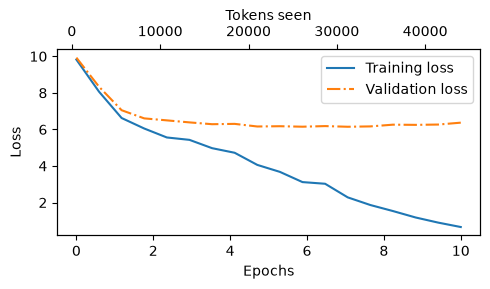

In [28]:
# pyplot 绘制损失曲线
import matplotlib.pyplot as plt
# ticker 用于设置 x 轴刻度标签的整数倍
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 绘制相对于 epoch的训练和验证损失
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # 仅在 x 轴上显示整数标签

    # 为已处理的 token 数量创建第二个 x 轴
    ax2 = ax1.twiny()  # 创建共享相同 y 轴的第二个 x 轴
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 用于对齐刻度的不可见图
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # 调整布局以腾出空间
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 查看上面的结果，我们可以看到模型开始生成难以理解的字符串，而到最后，它能够生成语法或多或少正确的句子
- 然而，根据训练和验证集损失，我们可以看到模型开始过度拟合
- 如果我们检查它最后写的一些段落，我们会发现它们逐字包含在训练集中 - 它只是记住训练数据
- 稍后，我们将介绍可以在一定程度上减轻这种记忆的解码策略
- 请注意，这里发生过度拟合是因为我们有一个非常非常小的训练集，并且我们对其进行了多次迭代
  - 这里的LLM 训练主要服务于教育目的；我们主要希望看到模型能够学习生成连贯的文本
  - 我们不再花费数周或数月在大量昂贵的硬件上训练该模型，而是稍后加载预训练的权重

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/13.webp" width=1000px>

**如果您有兴趣使用更先进的技术来增强此训练功能，例如学习率预热、余弦退火和梯度裁剪，请参阅[附录 D](../../appendix-D/01_main-chapter-code)**

**如果您对更大的训练数据集和更长的训练运行感兴趣，请参阅 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

 
## 5.3 控制随机性的解码策略（5.3 Decoding strategies to control randomness）

- 与我们上面训练的 GPT 模型一样，使用相对较小的 LLM 进行推理相对便宜，因此如果您使用 CPU 进行上面的训练，则无需使用 GPU
- 使用我们之前在简单训练函数中使用的 `generate_text_simple` 函数（来自上一章），我们可以一次生成一个单词（或标记）的新文本
- 如5.1.2节所述，下一个生成的token是词汇表中所有token中最大概率得分对应的token

In [29]:
# 新：这里使用 CPU，因为推理很便宜
# 这个模型并确保读者在
# 本书的其余部分
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- 即使我们多次执行上面的 `generate_text_simple` 函数，LLM 也将始终生成相同的输出
- 我们现在引入两个概念，即所谓的解码策略，来修改`generate_text_simple`：*温度缩放（temperature scaling）*和*top-k*采样
- 这些将使模型能够控制生成文本的随机性和多样性

 
### 5.3.1 温度缩放（5.3.1 Temperature scaling）

- 以前，我们总是使用 `torch.argmax` 采样概率最高的token作为下一个token
- 为了增加多样性，我们可以使用 `torch.multinomial(probs, num_samples=1)` 对下一个token进行采样，从概率分布中采样
- 这里，每个索引被选取的机会对应于它在输入张量中的概率

- 以下是生成下一个标记的一些回顾，出于说明目的，假设词汇量非常小：

In [30]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# 假设输入是“每一次努力都让你感动”，并且LLM
# 返回下一个标记的以下 logits：
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
#item()转tensor为number方便查字典
# 接下来生成的token如下：
print(inverse_vocab[next_token_id])

forward


In [31]:
#torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


- 我们不是通过 `torch.argmax` 确定最可能的标记，而是使用 `torch.multinomial(probas, num_samples=1)` 通过从 softmax 分布中采样来确定最可能的标记
- 出于说明目的，让我们看看当我们使用原始 softmax 概率对下一个标记进行 1,000 次采样时会发生什么：

In [32]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # 手动种子以提高重现性
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    #enumerate<->列举
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- 我们可以通过称为温度缩放的概念来控制分配和选择过程
- “温度缩放”只是一个花哨的词，用于将 logits 除以大于 0 的数字
- 应用 softmax 后，温度大于 1 将导致token概率分布更均匀
- 应用 softmax 后，小于 1 的温度将导致更自信（更尖锐或更尖峰）的分布

- 请注意，根据您的操作系统，最终的 dropout 输出可能看起来有所不同；您可以在 PyTorch 问题跟踪器](https://github.com/pytorch/pytorch/issues/121595) 上阅读有关这种不一致的更多信息

In [33]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# 温度值
temperatures = [1, 0.1, 5]  # 原始、置信度较高、置信度较低

# 计算比例概率
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

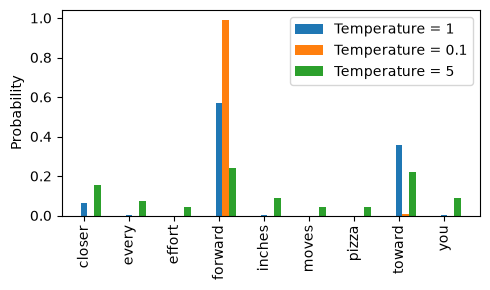

In [34]:
# 绘图
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- 我们可以看到，通过温度 0.1 进行重新缩放会产生更尖锐的分布，接近 `torch.argmax`，因此几乎总是选择最可能的单词：

In [35]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


- 通过温度 5 重新调整的概率分布更加均匀：

In [36]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- 假设 LLM 输入“everyeffort move you”，使用上述方法有时会产生无意义的文本，例如“everyeffort move you Pizza”，3.2% 的时间（1000 次中的 32 次）

 
### 5.3.2 Top-k 采样（5.3.2 Top-k sampling）

- 为了能够使用更高的温度来增加输出多样性并减少无意义句子的概率，我们可以将采样的标记限制为前 k 个最可能的标记：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=1000px>

-（请注意，该图中的数字被截断为两位
小数点后的数字可以减少视觉混乱。 Softmax 行中的值加起来应为 1.0。）

- 在代码中，我们可以按如下方式实现：

In [37]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [38]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> 注意：  
>
> 先前代码单元的另一种更高效的实现如下：
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
> <br>
> 更多详情请参见https://github.com/rasbt/LLMs-from-scratch/discussions/326

In [79]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


 
### 5.3.3 修改文本生成函数（5.3.3 Modifying the text generation function）

- 前两小节介绍了温度采样和top-k采样
- 让我们使用这两个概念来修改第 4 章中的 `generate_text_simple` 函数，创建一个新的 `generate` 函数：
- 原来的 generate_text_simple 只支持：

    argmax 贪心生成

- 新的 generate 支持：

    argmax

    temperature sampling

    top-k sampling
    
    遇到 eos 提前停止

In [39]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # 与之前一样循环生成：计算 logits，并只保留最后一个时间步
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # 新功能：使用 top_k 采样过滤 logits
        if top_k is not None:
            # 仅保留 top_k 值
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 新功能：应用温度缩放
        if temperature > 0.0:
            logits = logits / temperature

            # 新内容（不在书中）：在 mps 设备上获得等效结果的数值稳定性技巧
            # 在 softmax 之前减去 rowwise max
            # softmax(x) 和 softmax(x - max(x)) 结果一样,但能避免指数计算时数值过大
            logits = logits - logits.max(dim=-1, keepdim=True).values
            
            # 应用 softmax 得到概率分布
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # 从概率分布中采样
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # 否则与之前相同：获取具有最高 logits 值的词汇条目的 idx
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # 如果遇到序列结束 token 且指定了 eos_id，则提前停止生成
            break

        # 与之前相同：将采样索引附加到运行序列中
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [40]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise. It is to have been told Mrs.



 
## 5.4 在 PyTorch 中加载和保存模型权重（5.4 Loading and saving model weights in PyTorch）

- 训练 LLM 的计算成本很高，因此能够保存和加载 LLM 权重至关重要

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=1000px>

- PyTorch 中推荐的方法是通过将 `torch.save` 函数应用于 `.state_dict()` 方法来保存模型权重，即所谓的 `state_dict`：
- state_dict() 是一个字典，里面保存模型所有可训练参数。

- 比如：

    tok_emb.weight

    pos_emb.weight

    trf_blocks.0.att.W_query.weight


大概长这样：

{
    
    "tok_emb.weight": tensor(...),
    "pos_emb.weight": tensor(...),
    "trf_blocks.0.att.W_query.weight": tensor(...),
    "trf_blocks.0.att.W_key.weight": tensor(...),
    "trf_blocks.0.att.W_value.weight": tensor(...),
    ...
    "out_head.weight": tensor(...)

}

In [42]:
torch.save(model.state_dict(), "model.pth")

- 然后我们可以将模型权重加载到新的 `GPTModel` 模型实例中，如下所示：

In [43]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
    #backends.mps 
elif torch.backends.mps.is_available():
    # 使用 PyTorch 2.9 或更高版本获得稳定的 mps 结果
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cuda


- 使用 Adam 或 AdamW 等自适应优化器而不是常规 SGD 来训练 LLM 是很常见的（感兴趣的话可以了解一下为什么AdamW更适合GPT训练）
- 这些自适应优化器为每个模型权重存储附加参数，因此保存它们也是有意义的，以防我们计划稍后继续预训练：

In [44]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [45]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

 
## 5.5 从 OpenAI 加载预训练权重（5.5 Loading pretrained weights from OpenAI）

> **学习补充：加载权重时先核对形状**  
> 外部检查点的参数布局不一定与本章实现一致，尤其是 Q、K、V 合并矩阵及线性层权重。赋值前应逐项检查形状，并确认是否需要切分或转置；形状能对上并不自动代表语义顺序正确。

- 之前，我们仅使用一本非常小的短篇小说书来训练一个小型 GPT-2 模型，用于教育目的
- 感兴趣的读者还可以在 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)] 中找到完整的古腾堡计划图书语料库的更长预训练运行
- 幸运的是，我们不必花费数万到数十万美元在大型预训练语料库上预训练模型，而是可以加载 OpenAI 提供的预训练权重

---

---


⚠️ **注意：由于 TensorFlow 兼容性问题，某些用户可能会在本节中遇到问题，特别是在某些 Windows 系统上。这里只需要 TensorFlow 来加载原始 OpenAI GPT-2 权重文件，然后我们将其转换为 PyTorch。
如果您遇到 TensorFlow 相关问题，可以使用下面的替代代码来代替本节中的其余代码。
此替代方案基于预先转换的 PyTorch 权重，使用上一节中描述的相同转换过程创建。详细内容可以参考笔记本：
[../02_alternative_weight_loading/weight-loading-pytorch.ipynb](../02_alternative_weight_loading/weight-loading-pytorch.ipynb) 笔记本。**

```python
file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
gpt.to(device);


torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))
```

---

---

- 首先，一些样板代码用于从 OpenAI 下载文件并将权重加载到 Python 中
- 由于 OpenAI 使用 [TensorFlow](https://www.tensorflow.org/)，我们必须安装并使用 TensorFlow 来加载权重； [tqdm](https://github.com/tqdm/tqdm)是一个进度条库
- 取消注释并运行下一个单元以安装所需的库

In [46]:
# Windows: %pip install tensorflow-cpu tqdm
# Linux/macOS: %pip install tensorflow tqdm

In [46]:
print("TensorFlow version:", get_package_version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.21.0
tqdm version: 4.67.3


In [47]:
# 从此文件夹中包含的 gpt_download.py 进行相对导入

from gpt_download import download_and_load_gpt2
# 或者：
# 从 llms_from_scratch.ch05 导入 download_and_load_gpt2

---

**注意**

- 在极少数情况下，上面的代码单元可能会导致 `zsh: illegal hardware instruction python` 错误，这可能是由于计算机上的 TensorFlow 安装问题造成的
- 一位读者发现通过 `conda` 安装 TensorFlow 解决了这种特定情况下的问题，如[此处](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888)
- 您可以在本补充[Python设置教程](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda)]中找到更多说明

---

- 然后我们可以下载 1.24 亿参数模型的模型权重，如下所示：

In [50]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json


model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [1:32:09<00:00, 90.0kiB/s]  


File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta


vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 274kiB/s] 


In [51]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [52]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [53]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


- 另外，还支持“355M”、“774M”和“1558M” `model_size` 参数
- 这些不同尺寸型号之间的差异总结如下图：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/17.webp" width=1000px>

- 上面，我们将 124M GPT-2 模型权重加载到 Python 中，但是我们仍然需要将它们传输到我们的 `GPTModel` 实例中
- 首先，我们初始化一个新的 GPTModel 实例
- 请注意，原始 GPT 模型使用偏差向量初始化多头注意力模块中查询、键和值矩阵的线性层，这是不需要或推荐的；但是，为了能够正确加载权重，我们也必须通过在实现中将 `qkv_bias` 设置为 `True` 来启用这些权重
- 我们还使用原始 GPT-2 模型使用的 `1024` token上下文长度

In [53]:
# 在字典中定义模型配置以实现紧凑性
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# 复制基本配置并使用特定模型设置进行更新
model_name = "gpt2-small (124M)"  # 型号名称示例
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- 下一个任务是将 OpenAI 权重分配给 `GPTModel` 实例中相应的权重张量

In [54]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

| `params` 键         | 含义                          | 对应模型里的参数            | GPT-2 124M 常见形状 |
| ------------------ | --------------------------- | ---------------------- | --------------- |
| `params["wte"]`    | token embedding，词嵌入矩阵       | `gpt.tok_emb.weight`   | `[50257, 768]`  |
| `params["wpe"]`    | positional embedding，位置嵌入矩阵 | `gpt.pos_emb.weight`   | `[1024, 768]`   |
| `params["blocks"]` | 所有 Transformer Block 的参数列表  | `gpt.trf_blocks`       | 长度为 `12`        |
| `params["g"]`      | 最后一层 LayerNorm 的缩放参数 gamma  | `gpt.final_norm.scale` | `[768]`         |
| `params["b"]`      | 最后一层 LayerNorm 的平移参数 beta   | `gpt.final_norm.shift` | `[768]`         |


In [55]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

- 如果模型加载正确，我们可以使用它来使用我们之前的 `generate` 函数生成新文本：

In [56]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




- 我们知道我们正确加载了模型权重，因为模型可以生成连贯的文本；即使我们犯了一个小错误，模型也无法做到这一点

- 有关从 Hugging Face Hub 加载权重的替代方法，请参阅 [../02_alternative_weight_loading](../02_alternative_weight_loading)
- 如果您有兴趣了解 GPT 架构与 Llama 架构（Meta AI 开发的一种流行的 LLM）的比较，请参阅 [../07_gpt_to_llama](../07_gpt_to_llama)

 
## 总结和要点（Summary and takeaways）

- 请参阅[./gpt_train.py](./gpt_train.py) 脚本，一个用于训练的独立脚本
- [./gpt_generate.py](./gpt_generate.py) 脚本从 OpenAI 加载预训练权重并根据提示生成文本
- 您可以在[./exercise-solutions.ipynb](./exercise-solutions.ipynb)中找到练习解决方案